In [32]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [1]:
import os
import numpy as np
import pickle
import pandas as pd
from scipy.stats import zscore
from brainbox.io.one import SessionLoader
from sklearn.preprocessing import StandardScaler
import gc
import concurrent.futures
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate
import seaborn as sns 
import gzip

from segmentation_functions import plot_licks_PSTH, plot_whisker_psth

from one.api import ONE
one = ONE(mode='remote')

In [3]:
extra_sessions = ['2d7c0f7f-e805-404b-914a-23d83998e08e',
'7691eeb3-715b-4571-8fda-6bb57aab8253',
'a28746ff-a6e0-403d-a11d-893c2f9a44b4',
'f140a2ec-fd49-4814-994a-fe3476f14e66',
'bd8b204f-a42e-45c1-a8f0-71c6223a6657',
'e4fac833-d985-4bb2-a97a-c4d7ed8d06e1',
'13b70283-e8d3-4e69-ae3f-83f50c9602e2',
'e34ee0ad-3ad8-4faa-b4d5-c1cc0cf3b496',
'f3eeb2d4-87ce-49ae-8a74-21665f6f1536',
'd9f0c293-df4c-410a-846d-842e47c6b502',
'86f741b4-9dee-4c28-8ee9-49f3656ab419',
'650a0a90-4bf3-4489-9bcd-75baf0a49eac',
'a2be3311-de26-48b3-bfc7-317e94a4fdd3',
'12f95449-6914-4d76-9eb3-7d79757a4a77',
'd9907ac3-7378-471d-91fb-c8ec34870e17',
'b4a8ec28-46ad-4b6f-908b-650d0970a0db',
'c51f34d8-42f6-4c9c-bb5b-669fd9c42cd9',
'71963e7f-5947-4c3e-bcc8-dfdef3d71be7',
'7471a326-894d-4b55-8b01-a0ad56af209c',
'8839a67d-991a-4694-9c45-b3af73ce4d36',
'db4fe6df-b1d2-4958-9c93-e71696d58f7f',
'80653a5b-c7aa-479d-9ae0-c92f296fface',
'169c9a39-cb63-4b77-93e2-10e076d4c472',
'495bee7e-b58e-42ea-8481-4a1bfedca54a',
'1db57661-5ad3-4465-b9ee-08473af9c2e8',
'3513e7f2-d2e6-4411-8055-54dac50458f6',
'd035c5ba-d51e-49a9-a94b-23531a598ec3',
'6a369bfa-a70b-4147-af25-d03772ff8d96',
'7050ae29-a99e-43f1-aa42-b4416200351c',
'3fa080ff-bcce-43e8-bd5f-601f0591f785',
'369c3073-e886-4b28-a32b-a5860df21392',
'aa8c915b-cc12-4022-8339-3faa438d7fe2',
'8b422ab2-fc98-4d25-ac1f-e239ca869d9e',
'87d86bb0-72d3-4213-be72-392295d3d601',
'2ab80a04-96f6-45f8-bf69-7eac67f81742',
'57701dff-8107-4ab6-ac7a-b087a2e4cc94',
'42541dce-2ffb-452e-bf54-119aee2ae48a',
'89848cb4-77d3-4db2-877e-2fa73a3cf5f6',
'33cbe984-deb7-489c-add6-d98ac9f64df6',
'0b5f5111-5647-4400-8e08-f57975027b5e',
'9e77877d-6fcf-4e91-9337-4b19277561d5',
'dc36f1b9-5dba-49c4-b333-ad08af6b8f86',
'8a039e2b-637e-45ed-8da6-0641924626f0',
'00d3c9ea-2c91-44c2-b03e-6dfec5e08f27',
'e698b903-98ed-48b9-bc40-664274f722da',
'e5094e8a-cd54-43d4-8a7a-c5aa54b15e19',
'09137957-7216-40ea-90b5-ef85a62b578a',
'03f0ed7f-e647-4732-ae1a-d41fc459138b',
'4373de88-6b08-4185-a224-f898fd0017d4',
'30c4e2ab-dffc-499d-aae4-e51d6b3218c2',
'1e07df0b-205b-4c94-8e02-2ae07dae4347',
'5c7d2345-1f0e-40e5-aad7-2c6133b71b09',
'1735d2be-b388-411a-896a-60b01eaa1cfe',
'14736609-bfdd-4620-8e47-09d7f4bc4412',
'4537bd9a-0a63-4462-870c-5f6d70d289ed',
'1715d2bc-4da3-4de2-9631-3ab1c600f2bf',
'aed404ce-b3fb-454b-ac43-2f12198c9eaf',
'f115196e-8dfe-4d2a-8af3-8206d93c1729',
'5c454bcb-ae77-42da-a8d2-b6463ea9f21b',
'c728f6fd-58e2-448d-aefb-a72c637b604c',
'c8fc81e8-fd09-4228-a08c-81c01f21381a',
'7502ae93-7437-4bcd-9e14-d73b51193656',
'297bd519-78f8-45d2-af85-835e865e228f',
'7b074b1a-6576-4380-91e4-ad6cdf06c3a6',
'064a7252-8e10-4ad6-b3fd-7a88a2db5463']

In [5]:
""" Load BWM data post-QC """
gdrive_path = "/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/segmentation/"
filename = '1_bwm_qc_04-26-2026'
bwm_query = pickle.load(gzip.open(gdrive_path+filename, "rb"))

In [34]:
""" Load NM data post-QC """
path = '/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/'
sessions = list(pd.read_csv(path+'nm_filtered_eids.csv')['eid'])

In [38]:
""" Load training data BWM """
path = '/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/'
sessions = list(pd.read_csv(path+'lda_first_training_eids.csv')['eid'])

In [ ]:
# Loop through animals
# sessions = bwm_query['eid'].unique()
# sessions = extra_sessions
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/extra_bwm/'
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'
data_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/segmentation/design_matrices/'
data_path = prefix + 'representation_learning_variability/paper-individuality/segmentation/1_camera_setup/temp_data/design_matrices/'
data_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/design_matrices/1_camera_setup/session_1_individuality/' # data should be moved to the drive manually

In [39]:
os.chdir(data_path)
files = os.listdir()
sessions_to_process = []

for s, sess in enumerate(sessions):
    file_path = one.eid2path(sess)

    if prefix == '/home/ines/repositories/':
        mouse_name = file_path.parts[8]
    else:
        mouse_name = file_path.parts[7]

    filename = "design_matrix_" + str(sess) + '_'  + mouse_name
    if filename in files:
        sessions_to_process.append((sess))

len(sessions_to_process)

6

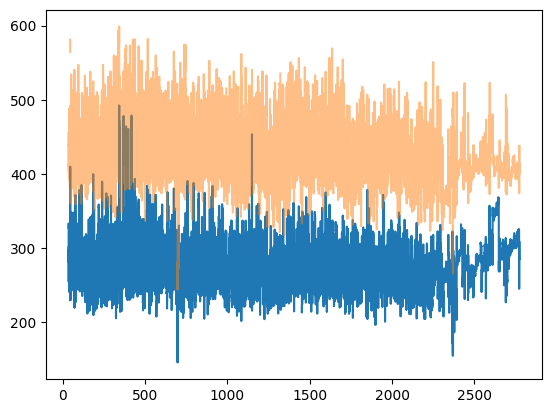

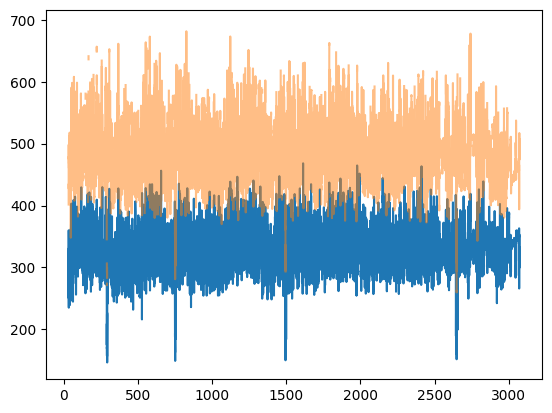

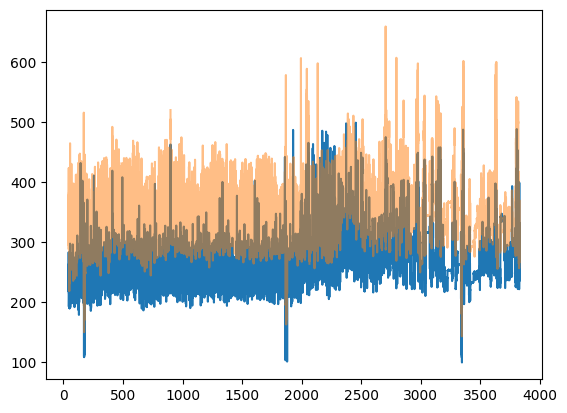

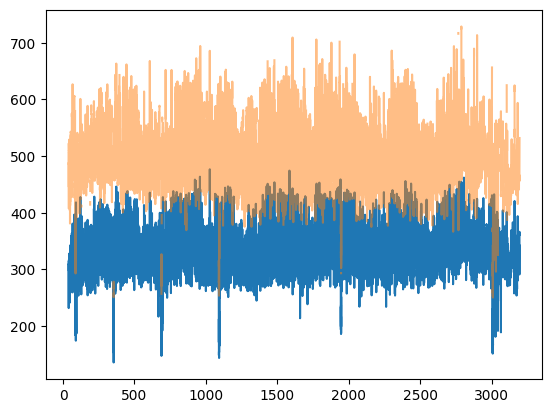

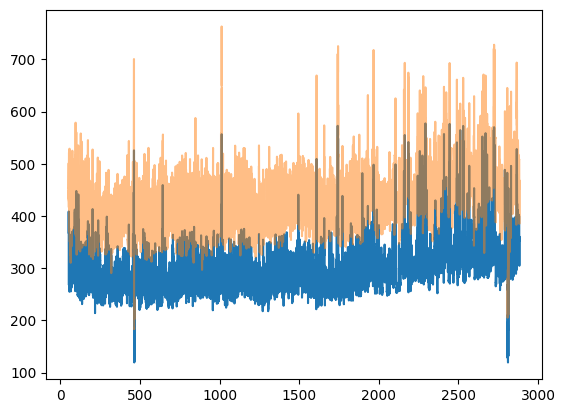

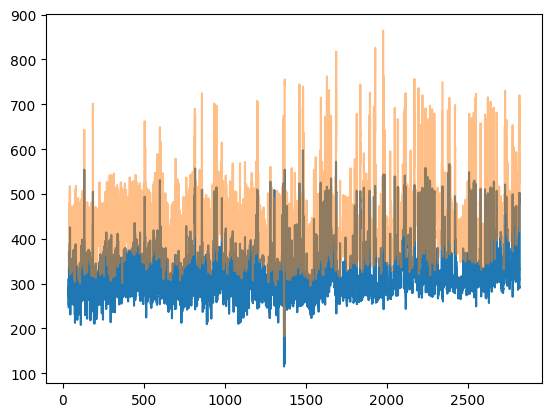

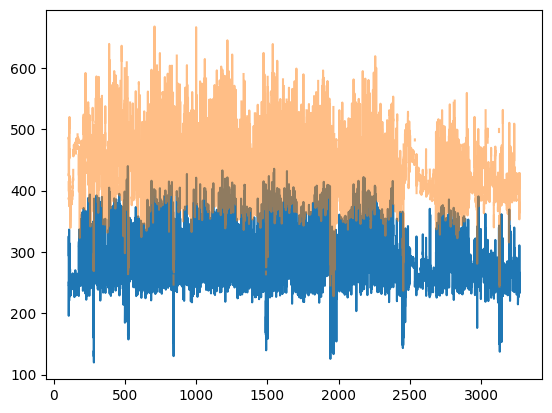

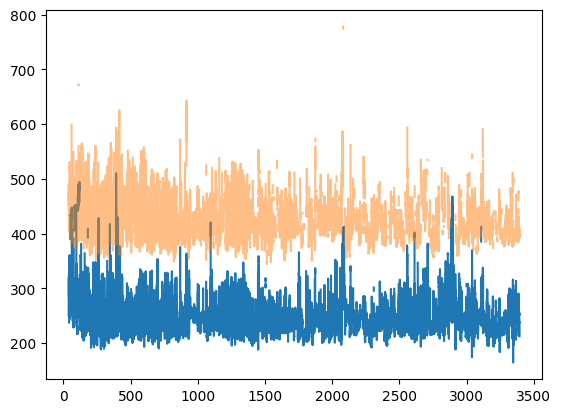

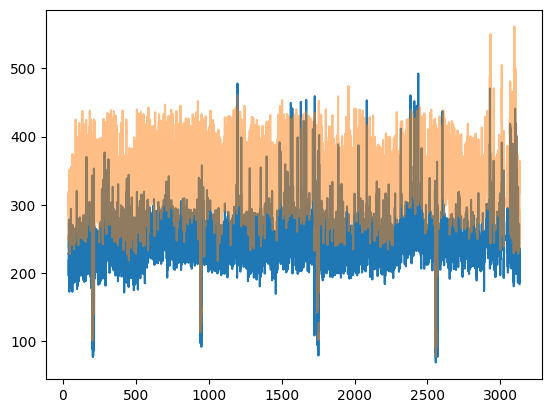

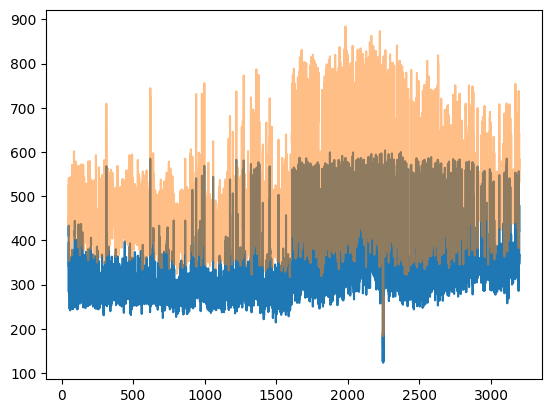

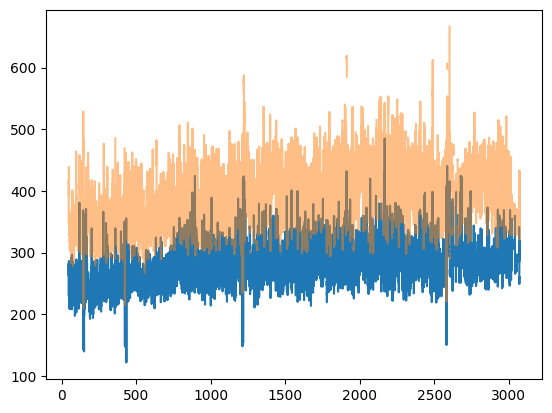

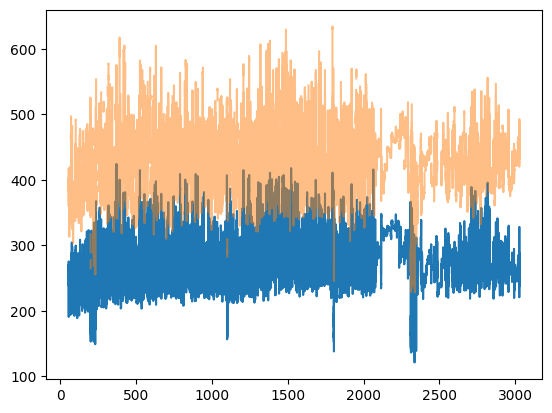

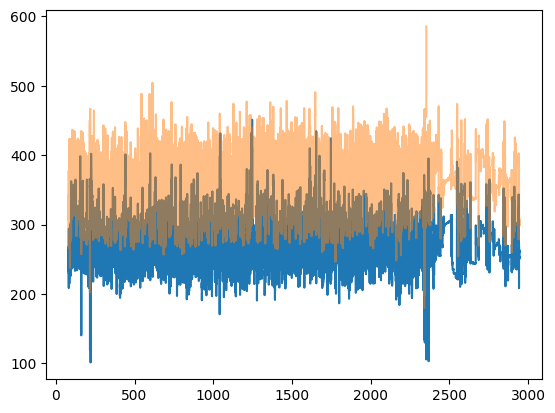

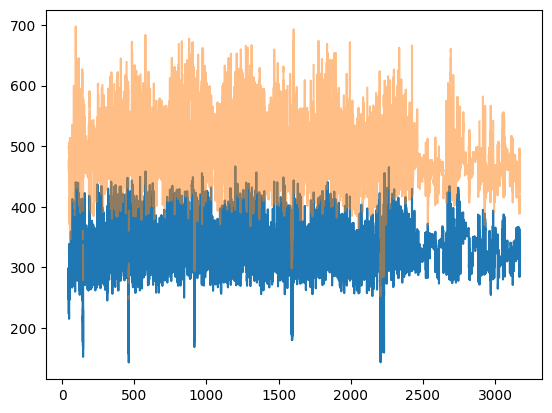

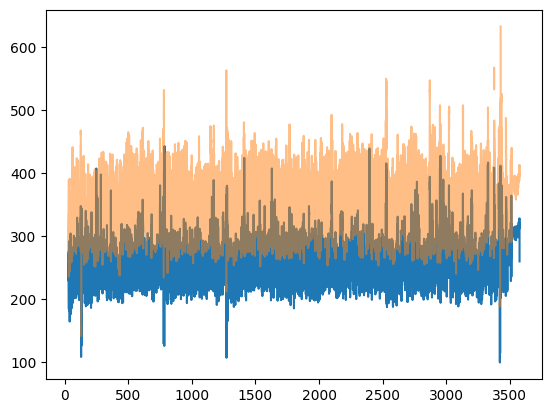

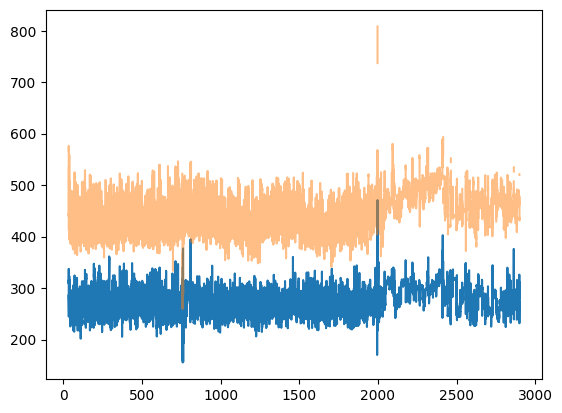

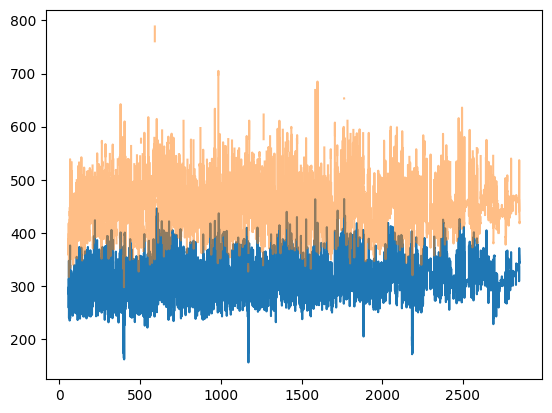

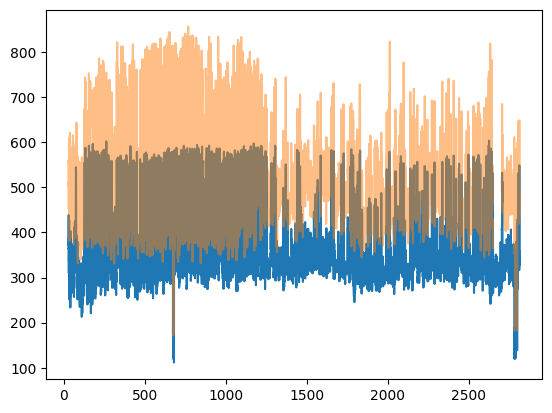

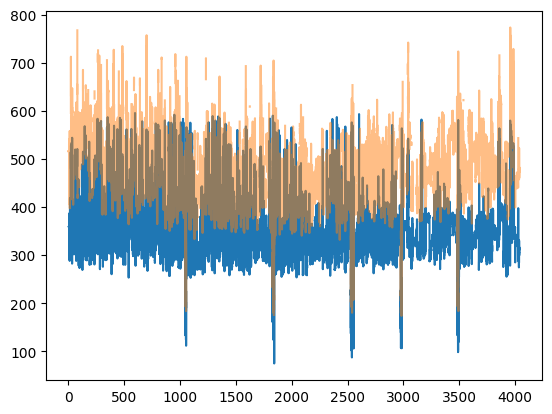

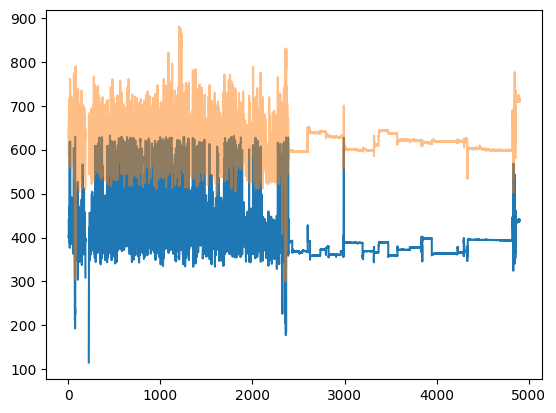

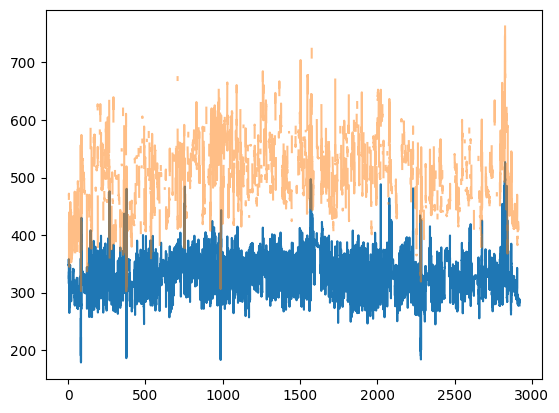

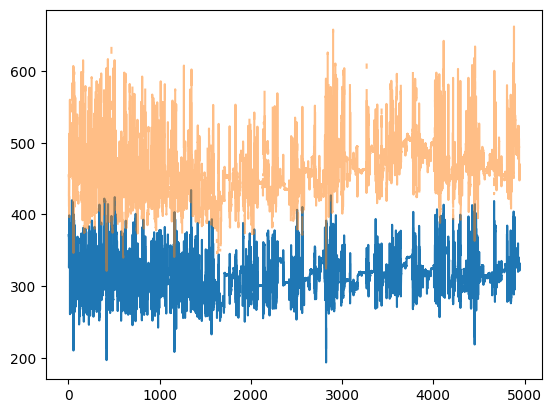

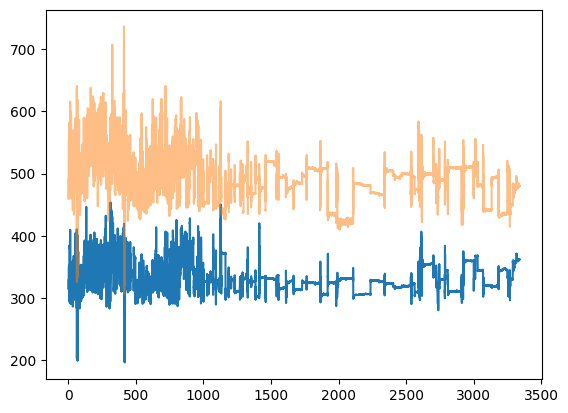

In [24]:
results_path = prefix + 'representation_learning_variability/paper-individuality/results/qc/design_matrix/'
results_path = prefix + 'representation_learning_variability/paper-individuality/segmentation/1_camera_setup/temp_data/qc_plots/'

for m, mat in enumerate(sessions_to_process):

    file_path = one.eid2path(mat)
    if prefix == '/home/ines/repositories/':
        mouse_name = file_path.parts[8]
    else:
        mouse_name = file_path.parts[7]

    session = mat
    filename = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)

    plt.plot(design_matrix['Bin'], design_matrix['l_paw_x']/2)
    plt.plot(design_matrix['Bin'], design_matrix['r_paw_x'], alpha=0.5)
    plt.show()

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/functions.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  licks_df = pd.concat([licks_df, temp_df])


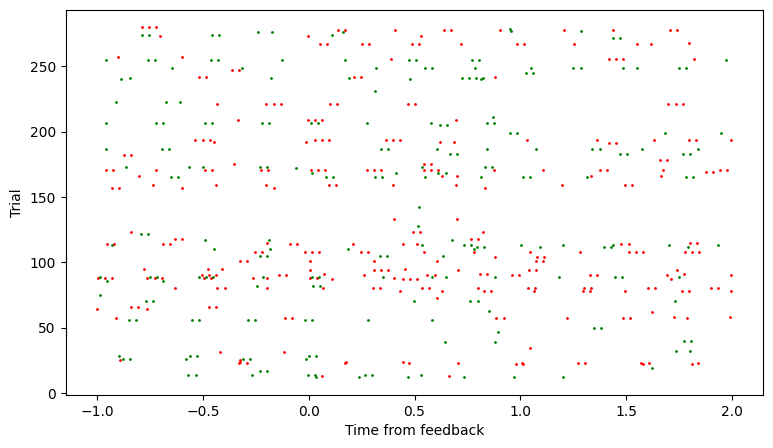

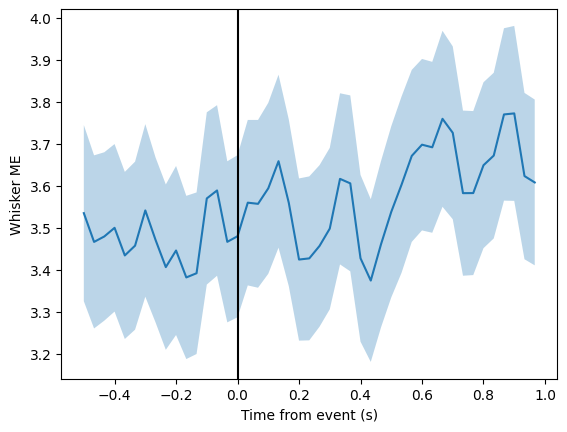

b117ed10-6871-42b3-9193-ca708dac4353


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/functions.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  licks_df = pd.concat([licks_df, temp_df])


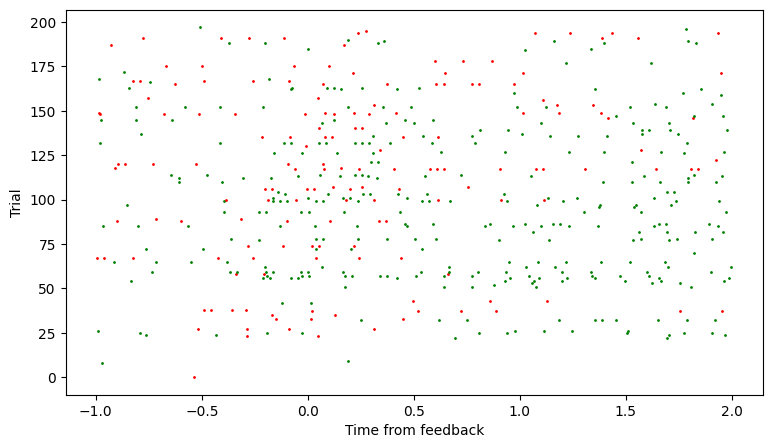

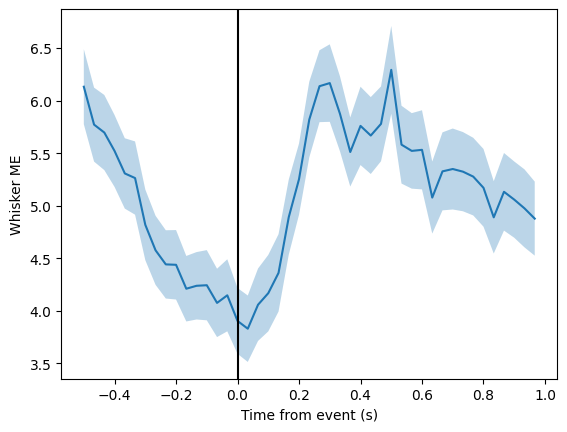

7331502c-ac8b-4d1c-ae35-b384e95088f4


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/functions.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  licks_df = pd.concat([licks_df, temp_df])


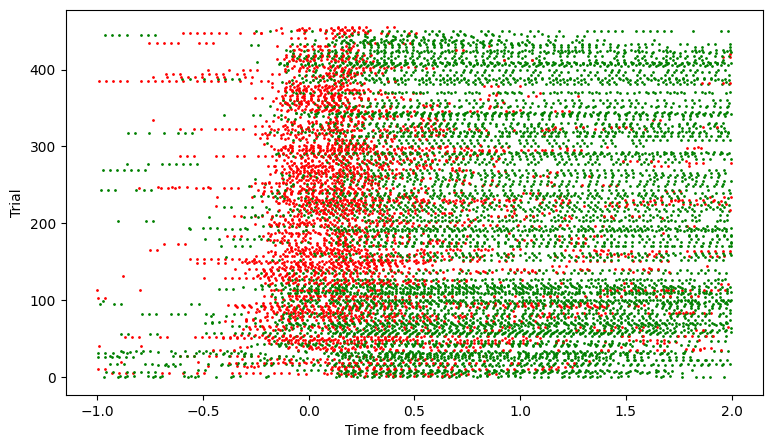

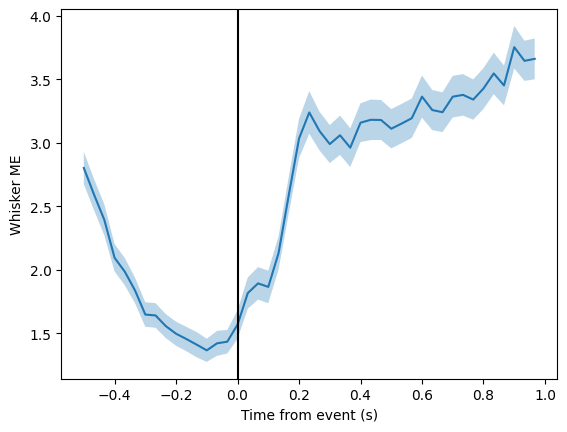

dc990d49-4e51-4759-992b-292fbe22a7eb


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/functions.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  licks_df = pd.concat([licks_df, temp_df])


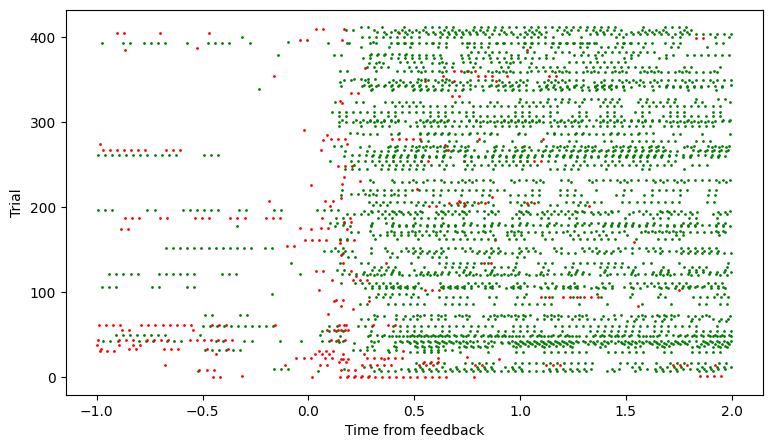

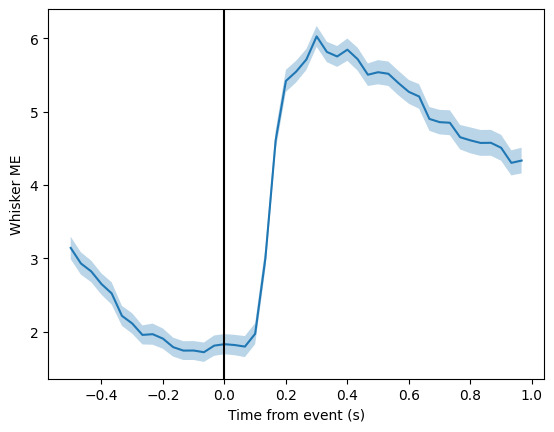

85da07f3-b1d4-439d-858d-5e0329a90b6f


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/functions.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  licks_df = pd.concat([licks_df, temp_df])


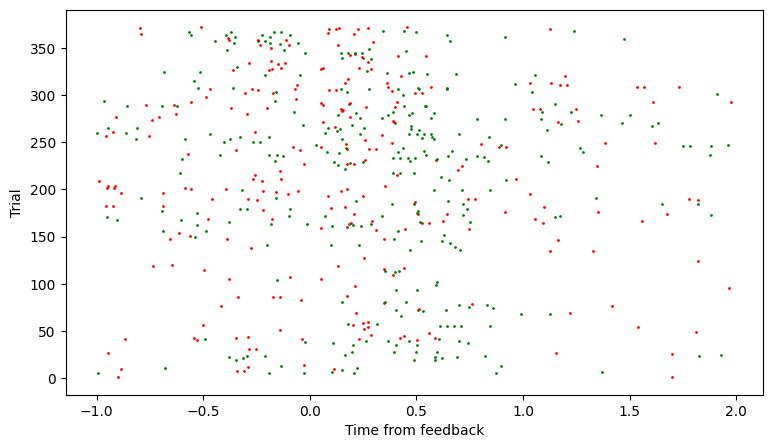

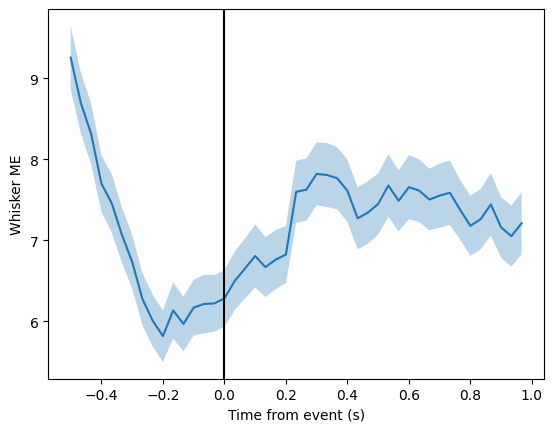

5d217d3f-0540-40b1-ad01-9b819ca3f504


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/functions.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  licks_df = pd.concat([licks_df, temp_df])


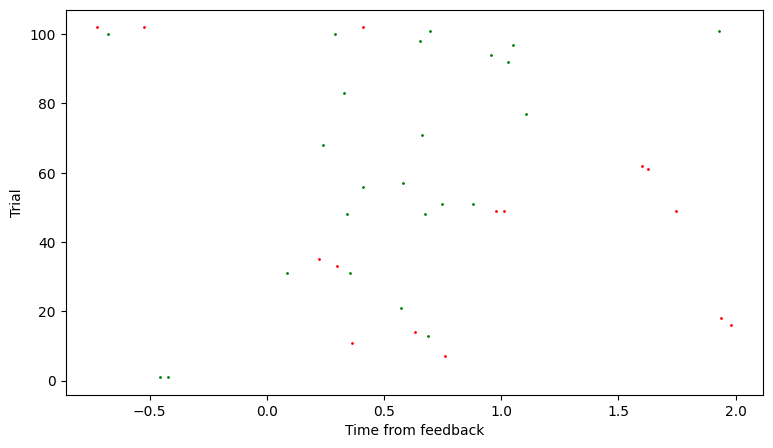

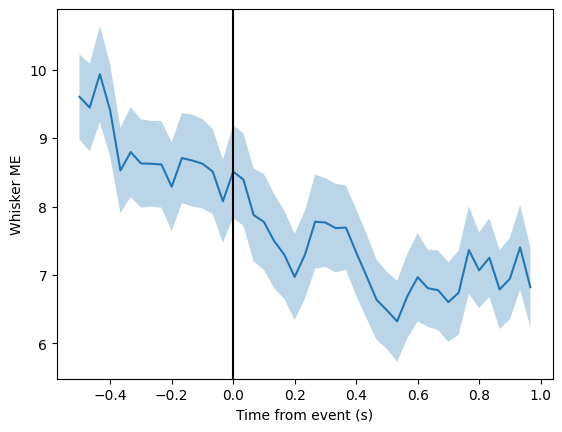

448e1454-01d6-4e51-ac45-9406d758a308


In [40]:
results_path = prefix + 'representation_learning_variability/paper-individuality/results/qc/design_matrix/extra_bwm/'
results_path = prefix + 'representation_learning_variability/paper-individuality/results/qc/design_matrix/'
results_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/segmentation/qc_inspection/'
results_path = prefix + 'representation_learning_variability/paper-individuality/segmentation/1_camera_setup/temp_data/qc_plots/'
results_path = ''
for m, mat in enumerate(sessions_to_process):
    

    file_path = one.eid2path(mat)
    if prefix == '/home/ines/repositories/':
        mouse_name = file_path.parts[8]
    else:
        mouse_name = file_path.parts[7]

    session = mat
    filename = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)

    # Get trials for corresponding session
    trials = one.load_object(mat, obj='trials', namespace='ibl')
    trial_df = trials.to_df()

    # Licking
    lick_times = np.array(design_matrix.loc[design_matrix['Lick count']==1, 'Bin'])
    plot_licks_PSTH(mat, trial_df, lick_times, results_path)

    # Whisking
    plot_whisker_psth(mat, design_matrix, trial_df, 'stimOnTrigger_times', results_path)

    # # Paws
    # plot_paw_hist(mat, design_matrix, results_path)
    # plot_paw_choice_psth(mat, design_matrix, trial_df, results_path)
    # plot_wheel_choicepsth(mat, design_matrix, trial_df, results_path)
    # plot_paw_left_feedbackpsth(mat, design_matrix, trial_df, results_path)
    # plot_paw_right_feedbackpsth(mat, design_matrix, trial_df, results_path)
    print(mat)


